In [2]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

RESULTS_DIR = Path('../results')
FIGURES_DIR = Path('../figures')
FIGURES_DIR.mkdir(exist_ok=True)

plt.rcdefaults()
plt.rcParams.update({
    'font.size':         11,
    'axes.titlesize':    13,
    'axes.labelsize':    11,
    'axes.spines.top':   False,
    'axes.spines.right': False,
    'axes.grid':         True,
    'grid.alpha':        0.3,
    'grid.linestyle':    '--',
    'legend.frameon':    False,
    'figure.dpi':        150,
})

COLORS = {
    'synthetic': '#2166ac',
    'lightbox':  '#4f0942',
    'sunlamp':   '#d6604d',
}
LABELS = {
    'synthetic': 'Synthetic (validation)',
    'lightbox':  'Lightbox HIL',
    'sunlamp':   'Sunlamp HIL',
}
DOMAINS = ['synthetic', 'lightbox', 'sunlamp']

In [3]:
scores = {}
for domain in DOMAINS:
    scores[domain] = np.load(RESULTS_DIR / f'anomaly_scores_mahal_{domain}.npy')

print(f"{'Domain':<12} {'N':>6} {'Mean':>12} {'Std':>12} {'P25':>12} {'Median':>12} {'P75':>12} {'P95':>12}")
print('-' * 90)
for domain in DOMAINS:
    s = scores[domain]
    print(f"{domain:<12} {len(s):>6} {s.mean():>12.1f} {s.std():>12.1f} "
          f"{np.percentile(s,25):>12.1f} {np.median(s):>12.1f} "
          f"{np.percentile(s,75):>12.1f} {np.percentile(s,95):>12.1f}")

Domain            N         Mean          Std          P25       Median          P75          P95
------------------------------------------------------------------------------------------
synthetic      1001         11.9         23.2          3.6          5.7         10.5         41.6
lightbox       1001      11512.7       3263.6      10048.4      12806.7      13516.5      14365.8
sunlamp        1001     148429.8      25235.2     132284.6     152090.7     168540.7     182445.8


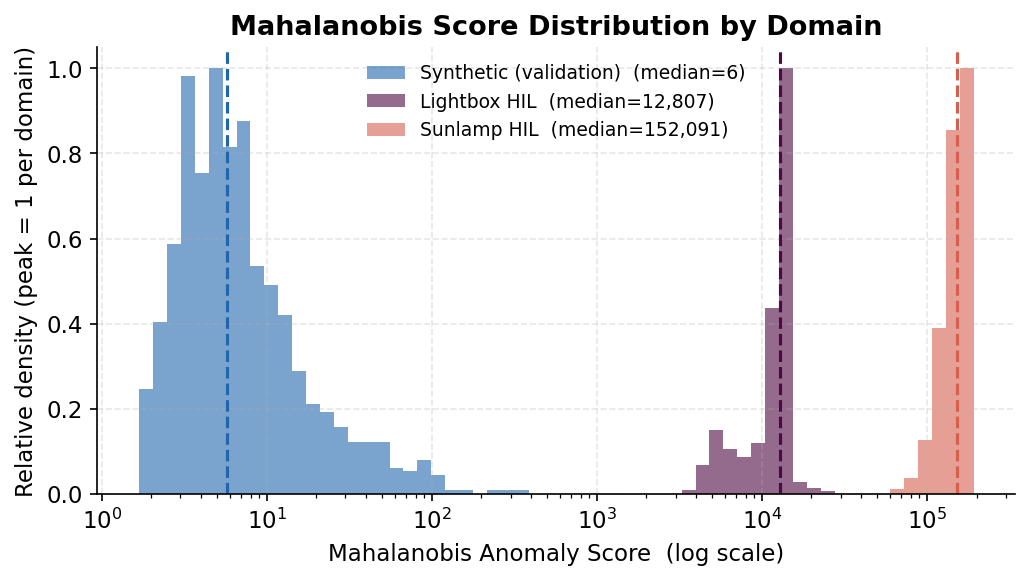

In [4]:
# Overlay on log scale — shows the 4-order-of-magnitude domain separation.
# Each domain is normalized to its own peak so all three distributions are
# visible despite spanning very different density scales.
fig, ax = plt.subplots(figsize=(7, 4))

all_scores = np.concatenate([scores[d] for d in DOMAINS])
bins = np.logspace(np.log10(all_scores.min() + 1), np.log10(all_scores.max()), 61)

for domain in DOMAINS:
    s = scores[domain]
    counts, edges = np.histogram(s, bins=bins)
    # normalize so each domain's tallest bar = 1
    rel = counts / counts.max()
    widths = np.diff(edges)
    ax.bar(
        edges[:-1], rel, width=widths, align='edge',
        color=COLORS[domain], alpha=0.6,
        label=f"{LABELS[domain]}  (median={np.median(s):,.0f})",
    )
    ax.axvline(np.median(s), color=COLORS[domain], linestyle='--', linewidth=1.5)

ax.set_xscale('log')
ax.set_xlabel('Mahalanobis Anomaly Score  (log scale)')
ax.set_ylabel('Relative density (peak = 1 per domain)')
ax.set_title('Mahalanobis Score Distribution by Domain', fontweight='bold')
ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'mahal_scores_overlay.pdf', bbox_inches='tight')
plt.savefig(FIGURES_DIR / 'mahal_scores_overlay.png', bbox_inches='tight')
plt.show()

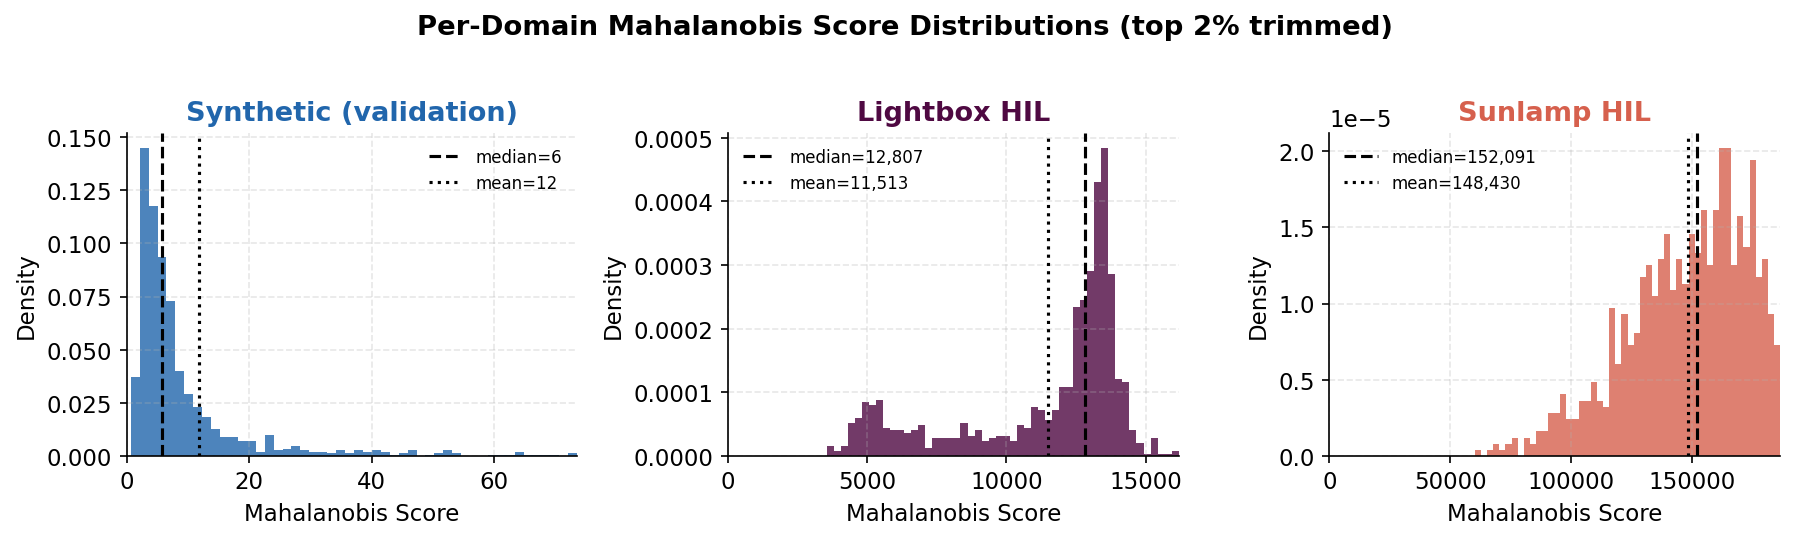

In [5]:
# Per-domain histograms on linear scale — shows the within-domain shape
fig, axes = plt.subplots(1, 3, figsize=(12, 3.5))

for ax, domain in zip(axes, DOMAINS):
    s = scores[domain]
    cap = np.percentile(s, 98)
    # filter rather than clip — clipping piles values at cap, inflating the last bar
    s_trimmed = s[s <= cap]

    ax.hist(
        s_trimmed, bins=50,
        color=COLORS[domain], alpha=0.8,
        density=True, edgecolor='none',
    )
    ax.axvline(np.median(s), color='black', linestyle='--', linewidth=1.5,
               label=f'median={np.median(s):,.0f}')
    ax.axvline(np.mean(s), color='black', linestyle=':', linewidth=1.5,
               label=f'mean={np.mean(s):,.0f}')

    ax.set_title(LABELS[domain], color=COLORS[domain], fontweight='bold')
    ax.set_xlabel('Mahalanobis Score')
    ax.set_ylabel('Density')
    ax.legend(fontsize=8)
    ax.set_xlim(0, cap)

fig.suptitle('Per-Domain Mahalanobis Score Distributions (top 2% trimmed)',
             fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'mahal_scores_per_domain.pdf', bbox_inches='tight')
plt.savefig(FIGURES_DIR / 'mahal_scores_per_domain.png', bbox_inches='tight')
plt.show()

Key takeaways from plots above:
  - Synthetic: tight, concentrated distribution (scores 0–50 or so) — synthetic images are all similar to each other
  - Lightbox: broader spread — more variability in how anomalous HIL images look
  - Sunlamp: broadest spread, shifted far right — the harsh artificial sun creates extreme and varied domain shift